In [ ]:
# Install dependencies

!pip install -q underthesea; seaborn; wordcloud; py_vncorenlp; datasets; kagglehub

In [1]:
# Import dependency
import os
import re
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py_vncorenlp
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from underthesea import word_tokenize
from wordcloud import WordCloud
import kagglehub


d:\projects\@uit_projects\uit-labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [87]:
DATA_DIR = Path("../../data")

DATA_DIR.resolve()

# path = kagglehub.dataset_download("cthng123/hate-speech-detection-vietnamese", output_dir=str(DATA_DIR.resolve()))
# print("Path to dataset files:", path)

WindowsPath('D:/projects/@uit_projects/uit-labs/data')

In [3]:
# Vietnamese Stopwords
_stopwords = set([
    # stop word
    "thì", "là", "và", "của", "những", "các", "tại", "bị", "bởi", "với", "để", 
    "như", "này", "đó", "kia", "trong", "trên", "dưới", "cho", "về", "khi",
    "có", "không", "gì", "nào", "đâu", "rồi", "lại", "vẫn", "cũng", "đang",
    "đã", "sẽ", "phải", "nhưng", "tuy", "hoặc", "nếu", "vì", "mà", "ai", 
    "nó", "họ", "ta", "ông", "bà", "anh", "chị", "em", "mình", "cậu", "bạn",
    "người", "được", "ra", "vào", "lên", "xuống", "đi", "đến", "qua", "lắm",
    "rất", "quá", "ơi", "à", "ừ", "nhé", "nhỉ", "cả", "chi", "chứ", "kìa" ,

     # Đại từ nhân xưng mở rộng
    "tôi", "tao", "mày", "tụi", "chúng", "chúng tôi", "chúng ta",
    "hắn", "này", "kia", "đấy", "ấy",
    
    # Trợ từ, từ đệm, từ cảm thán
    "à", "á", "ạ", "ơ", "ờ", "ừ", "uh", "ồ", "ôi", "wow",
    "ha", "hả", "hử", "ơ", "ok", "okay",

    # Từ chỉ thời gian chung chung
    "hôm", "nay", "qua", "mai", "nữa", "luôn", "liền",

    # Từ chỉ địa điểm chung chung
    "đây", "đấy", "kia", "đó",

    # Từ nối mở rộng
    "song", "như thể", "giống như", "tuy nhiên", "bởi vì",
    "ngoài ra", "thậm chí",

    # Từ phủ định
    "chẳng", "chả", "không hề", "chưa", "chẳng hề",

    # Từ chỉ mức độ/nhấn mạnh
    "siêu", "quá trời", "cực", "vô cùng", "hết sức", "kinh",
    "khá", "hơi", "đậm", "nhẹ", "toàn", "toàn là",

    # Từ chỉ số lượng chung chung
    "một ít", "một chút", "ít", "nhiều", "mọi", "tất cả", "mỗi",

    # Từ hội thoại phổ biến
    "vậy", "thế", "thôi", "nhé", "nhỉ", "chứ gì", "mà nhỉ",
    "haizz", "haha", "hihi", "kkk",

    # Biến thể không dấu (hỗ trợ text thiếu dấu)
    "thi", "la", "va", "cua", "nhung", "cac", "tai", "bi",
    "boi", "voi", "de", "nhu", "nay", "do", "kia", "trong",
    "tren", "duoi", "cho", "ve", "khi", "co", "khong", "gi",
    "n nao", "dau", "roi", "lai", "van", "cung", "dang",
    "da", "se", "phai", "nhung", "tuy", "hoac", "neu",
    "vi", "ma", "ai", "no", "ho", "ta", "ong", "ba", "anh",
    "chi", "em", "minh", "cau", "ban", "nguoi", "duoc",
    "ra", "vao", "len", "xuong", "di", "den", "qua",
    "lam", "rat", "qua", "oi", "a", "u", "nhe", "nhi",
    "ca", "chi", "chu", "kia"
])


In [4]:
MODELS_PATH = Path("./vncorenlp_models")
if MODELS_PATH.exists():
    shutil.rmtree(MODELS_PATH)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

model_path = str(MODELS_PATH.resolve())

# Download toàn bộ model files
py_vncorenlp.download_model(save_dir=model_path)
# Chỉ load word segmentation
rdrsegmenter = py_vncorenlp.VnCoreNLP(
    annotators=["wseg"],
    save_dir=model_path
)

In [89]:
# from datasets import load_dataset

# train = load_dataset("sonlam1102/vihsd", split="train").to_pandas()
# dev = load_dataset("sonlam1102/vihsd", split="validation").to_pandas()
# test = load_dataset("sonlam1102/vihsd", split="test").to_pandas()

# df_full = pd.concat([train, dev, test], ignore_index=True) 
# df_full.rename(columns={df_full.columns[0]: 'comments', df_full.columns[1]: 'label'}, inplace=True)
# df_full.dropna(subset=['comments', 'label'], inplace=True)
# df_full.drop_duplicates(subset=['comments'], inplace=True)

# Load datasets
df_train = pd.read_csv(Path(f'{DATA_DIR}/train_df.csv').resolve())
df_test = pd.read_csv(Path(f'{DATA_DIR}/test_df.csv').resolve())
df_val = pd.read_csv(Path(f'{DATA_DIR}/val_df.csv').resolve())

df_full = pd.concat([df_train, df_test, df_val], ignore_index=True)

df_full.rename(columns={df_full.columns[0]: 'comments', df_full.columns[1]: 'label'}, inplace=True)

df_full.dropna(subset=['comments', 'label'], inplace=True)
df_full.drop_duplicates(subset=['comments'], inplace=True)


# Path(f'{DATA_DIR}/train_df.csv').resolve()


In [90]:
def cleaner(text: str) -> str:
    re_text = str(text).lower()

    re_text = re.sub(r'http\S+', '', re_text)
    re_text = re.sub(r'[^\w\s]', ' ', re_text)
    re_text = re.sub(r'\s+', ' ', re_text).strip()

    words = re_text.split()
    words = [w for w in words if w not in _stopwords]
    words = " ".join(words)
    return words

df_full["comments"] = df_full["comments"].apply(cleaner)

df_full["text_tokenized"] = df_full["comments"].apply(
    lambda t: rdrsegmenter.word_segment(t)[0]
    if isinstance(t, str) and t.strip()
    else ""
)

display(df_full[['comments', 'label', 'text_tokenized']].head(10))

,comments,label,text_tokenized
0,cặc,1.0,cặc
1,đr hết thời cày rank bk còn ngợp,0.0,đr hết thời cày rank bk còn ngợp
2,diễn viên hô ni hút ngại mấy khác kk,0.0,diễn_viên hô ni hút ngại mấy khác kk
3,bọn vô công nghề ngồi sủa ăn lương tháng vinh ...,2.0,bọn vô công nghề ngồi sủa ăn lương tháng vinh_...
4,kim cương bố ỉa mồm cái lối đồ 10 game 1 bao g...,1.0,kim_cương bố ỉa mồm cái lối đồ 10 game 1 bao_g...
5,con làm lòng vòng tìm cách tham ô tham nhũng x...,1.0,con làm lòng_vòng tìm cách tham_ô tham_nhũng x...
6,why cái lồn,1.0,why cái lồn
7,su quỳnh chéo avt hô vs,0.0,su quỳnh chéo avt hô vs
8,phàm vlon thanh niên,1.0,phàm vlon thanh_niên
9,bă t đươ c mâ y thă ng trô m xe nên chă t tay,1.0,bă t đươ c mâ y thă ng trô m xe nên chă t tay


,Count,Percentage
Non-cyberbullying,2980,44.1
Offensive,1960,29.0
Hate speech,1818,26.9


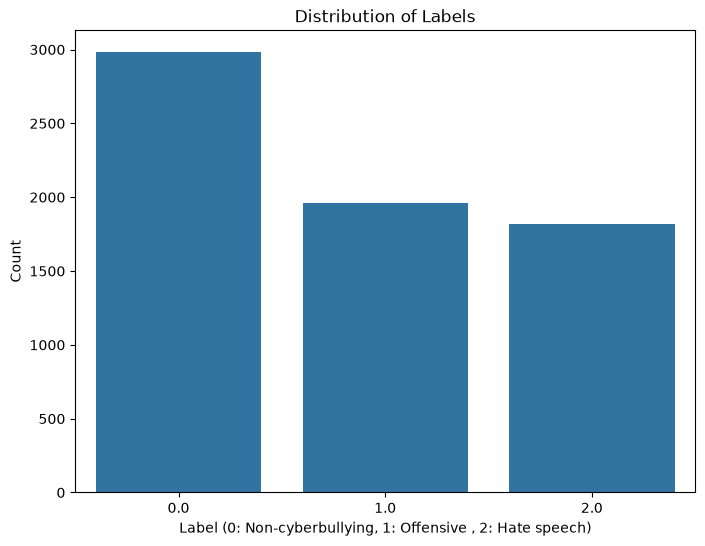

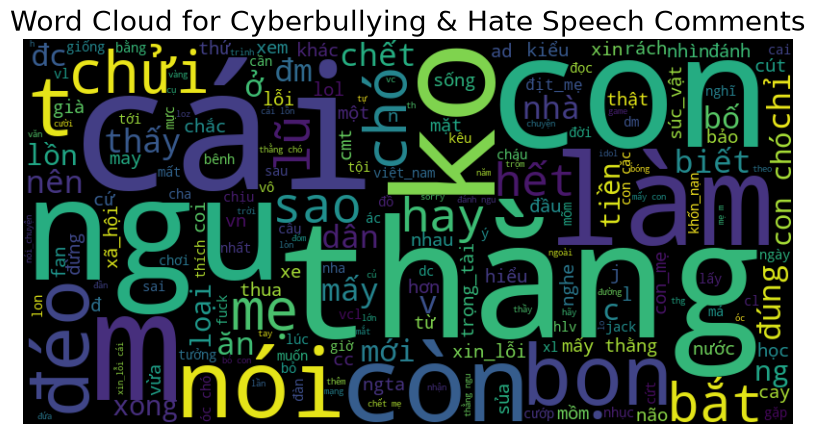

In [91]:
toxicity_counts = df_full['label'].value_counts()
toxicity_percentages = df_full['label'].value_counts(normalize=True) * 100

toxicity_distribution = pd.DataFrame({
    'Count': toxicity_counts,
    'Percentage': toxicity_percentages.round(2)
})

toxicity_distribution.index = ['Non-cyberbullying', 'Offensive', 'Hate speech']
display(toxicity_distribution)

plt.figure(figsize=(8, 6))
sns.countplot(data=df_full, x="label")
plt.title("Distribution of Labels")
plt.xlabel("Label (0: Non-cyberbullying, 1: Offensive , 2: Hate speech)")
plt.ylabel("Count")
plt.show()

# Word Cloud Visualization
def generate_wordcloud(text_series, title):
    text = " ".join(text_series)
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

generate_wordcloud(df_full[df_full['label'] != 0]['text_tokenized'], "Word Cloud for Cyberbullying & Hate Speech Comments")



In [92]:
X = df_full['text_tokenized']
y = df_full['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Kích thước Train: {len(X_train)} | Kích thước Test: {len(X_test)}")

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2, max_df=0.8, sublinear_tf=True)),
    ('regressor', LinearSVR(epsilon=0.1, C=1.0, max_iter=10000, random_state=42))
])

pipeline.fit(X_train, y_train)

Kích thước Train: 5406 | Kích thước Test: 1352


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.8
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'stri

Mean Squared Error (MSE): 0.3052
Classification Report:
                    precision    recall  f1-score   support

Non-cyberbullying       0.69      0.95      0.80       596
    Cyberbullying       0.94      0.66      0.77       756

         accuracy                           0.79      1352
        macro avg       0.81      0.80      0.78      1352
     weighted avg       0.83      0.79      0.78      1352



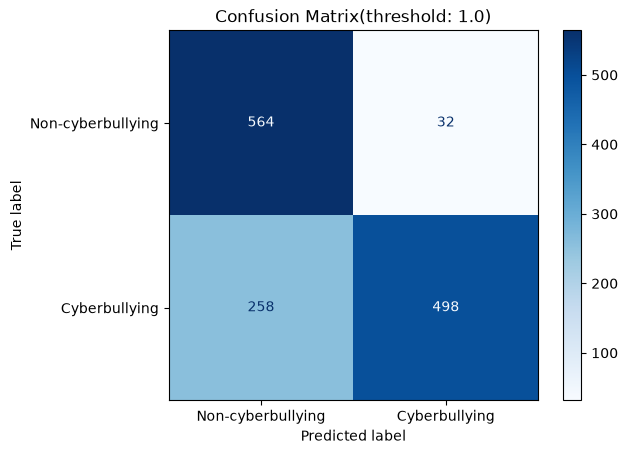

In [51]:
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

threshold = 1.0

y_pred_binary = [1 if score >= threshold else 0 for score in y_pred]
y_true_binary = [1 if label >= threshold else 0 for label in y_test]

class_report = classification_report(y_true_binary, y_pred_binary, target_names=['Non-cyberbullying', 'Cyberbullying'])
print("Classification Report:\n", class_report)

cm = confusion_matrix(y_true_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-cyberbullying', 'Cyberbullying'])
disp.plot(cmap=plt.cm.Blues)
disp.ax_.set_title(f"Confusion Matrix(threshold: {threshold})")
plt.show()


Best Threshold: 0.5614
Best F1 Score: 0.8612


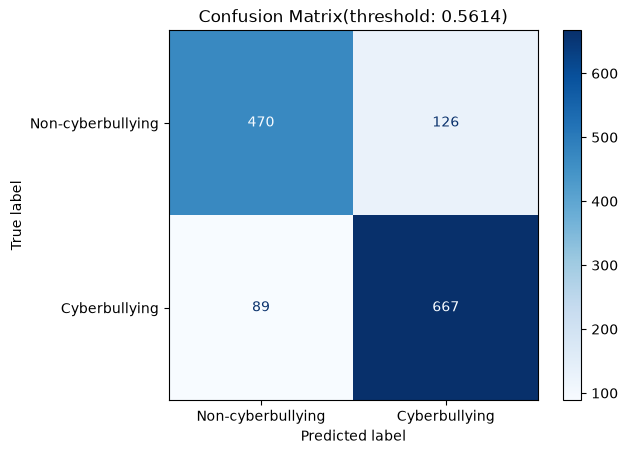

In [93]:
from sklearn.metrics import precision_recall_curve


y_true_binary = [1 if label >= threshold else 0 for label in y_test]

precision, recall, thresholds  = precision_recall_curve(y_true_binary, y_pred)

numerator = 2 * precision * recall
denominator = precision + recall
f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1_score = f1_scores[best_threshold_index]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1_score:.4f}")

y_pred_optimal = [1 if score >= best_threshold else 0 for score in y_pred]

cm = confusion_matrix(y_true_binary, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-cyberbullying', 'Cyberbullying'])
disp.plot(cmap=plt.cm.Blues)
disp.ax_.set_title(f"Confusion Matrix(threshold: {best_threshold:.4f})")
plt.show()
 

In [94]:
model_filename = 'toxic_detect_model.pkl'
joblib.dump(pipeline, model_filename)
print(f"Mô hình đã được lưu thành công tại: {model_filename}")

Mô hình đã được lưu thành công tại: toxic_detect_model.pkl


In [95]:
import joblib

THRESHOLD = best_threshold


class ToxicFilterSystem:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)
        print("System loaded successfully.")
    
    def _preprocess(self, text):
        # Đảm bảo logic tiền xử lý giống hệt lúc train
        if not text: return ""
        text = str(text).lower()
        return rdrsegmenter.word_segment(text)[0]

    def analyze(self, text):
        tokenized_text = self._preprocess(text)
        score = self.model.predict([tokenized_text])[0]
        score = round(score, 3)
        
        # Logic nghiệp vụ
        if score <= threshold:
            label = "safe"
            message = "✅ Nội dung hợp lệ"
       
        else:
            label = "block"
            message = "❌ Vi phạm tiêu chuẩn cộng đồng"
            
        return {
            "original_text": text,
            "toxicity_score": score,
            "label": label,
            "message": message
        }

# --- DEMO SỬ DỤNG ---
filter_sys = ToxicFilterSystem('toxic_detect_model.pkl')

test_comments = [
    "Shop giao hàng nhanh quá, cảm ơn nhé",
    "Sản phẩm như cái quần què, phí tiền",
    "đ ồ n g ố c thật sự 😭",
    "Đúng là n.g.u hết chỗ nói.",
    "đm lừa đảo à",
    "Hay quá ha, thông minh dữ chưa :)))",
    "Nó bảo tôi là \"đồ ngu\", chứ tôi có chửi nó đâu.",
    "Tôi không hề nói nó ngu, tôi chỉ nói cách làm này hơi khó hiểu thôi.",
    "Team này đánh hay quá, hay tới mức 0-10 luôn 🤡",
    "Bạn tôi nói câu \"cút đi đồ vô dụng\" nghe khá nặng.",
    "ngu??? không, phải gọi là \"thiên tài chiến thuật\" mới đúng :)))",
    "Tôi ghét hành vi của nhóm đó, không phải ghét những người thuộc nhóm đó.",
    "Nhin cái cách bạn ấy nói chuyện, tôi thấy hơi khó chịu.",
    "Tôi không thích cách bạn ấy nói chuyện, nhưng tôi không ghét bạn ấy.",
    "E thang cu ti, ve nha chet me may voi tao",
    
]

for cmt in test_comments:
    result = filter_sys.analyze(cmt)
    print(f"[{result['label'].upper()}] Score: {result['toxicity_score']} | {result['original_text']} |  {result['message']}")

System loaded successfully.
[SAFE] Score: -0.077 | Shop giao hàng nhanh quá, cảm ơn nhé |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.846 | Sản phẩm như cái quần què, phí tiền |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.006 | đ ồ n g ố c thật sự 😭 |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.586 | Đúng là n.g.u hết chỗ nói. |  ✅ Nội dung hợp lệ
[BLOCK] Score: 1.36 | đm lừa đảo à |  ❌ Vi phạm tiêu chuẩn cộng đồng
[SAFE] Score: 0.244 | Hay quá ha, thông minh dữ chưa :))) |  ✅ Nội dung hợp lệ
[BLOCK] Score: 1.364 | Nó bảo tôi là "đồ ngu", chứ tôi có chửi nó đâu. |  ❌ Vi phạm tiêu chuẩn cộng đồng
[SAFE] Score: 0.18 | Tôi không hề nói nó ngu, tôi chỉ nói cách làm này hơi khó hiểu thôi. |  ✅ Nội dung hợp lệ
[SAFE] Score: 0.315 | Team này đánh hay quá, hay tới mức 0-10 luôn 🤡 |  ✅ Nội dung hợp lệ
[BLOCK] Score: 1.119 | Bạn tôi nói câu "cút đi đồ vô dụng" nghe khá nặng. |  ❌ Vi phạm tiêu chuẩn cộng đồng
[BLOCK] Score: 2.078 | ngu??? không, phải gọi là "thiên tài chiến thuật" mới đúng :))) |  ❌ Vi phạm tiêu chuẩn cộng